# 01. Creating Various Chart Types

## Using Matplotlib and Seaborn

## 📚 Learning Objectives

By completing this notebook, you will:
- Create various chart types (line, bar, scatter, histogram, etc.)
- Use Matplotlib for basic plotting
- Use Seaborn for statistical visualizations
- Choose appropriate chart types for your data
- Customize charts for presentations

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 2, lesson 05 "EDA: Visualizing Data Distributions" — the same charts, now chosen deliberately: which chart answers which question.

**Used later in:** Course 05 — Unit 3, lessons 02-08, which go deeper on each library, and Course 12 (AIAT 126) — Unit 5.

---

This notebook covers practical activities from **Course 05, Unit 3**:
- Creating various chart types using Matplotlib and Seaborn

---

## The Story: Learning to Draw

Imagine you're learning to draw. **Before** creating masterpieces, you learn basic shapes - circles, squares, lines. **After** mastering basics, you can combine them into complex drawings!

Same with visualization: **Before** creating advanced dashboards, we learn basic chart types - line, bar, scatter. **After** mastering basics, we can create any visualization!

---

## Why Chart Types Matter

Understanding chart types is essential because:
- **Right Tool**: Each chart type shows different insights
- **Communication**: Visuals communicate better than tables
- **Decision Making**: Charts help make data-driven decisions
- **Professionalism**: Good charts impress stakeholders

**Common Student Questions:**
- **Q: Which chart should I use?**
  - Answer: Depends on your data and goal
  - Example: Trends over time → line plot, Compare categories → bar chart
  - Rule: Time series → line, Categories → bar, Relationships → scatter
  
- **Q: Matplotlib vs Seaborn?**
  - Answer: Matplotlib for basic plots, Seaborn for statistical plots
  - Example: Simple bar chart → matplotlib, Statistical distribution → seaborn
  - Tip: Start with matplotlib, use seaborn for advanced statistics

---

## Introduction

**Matplotlib and Seaborn** provide comprehensive tools for creating various chart types. Understanding when to use each chart type is essential for effective data visualization and communication.


## 🎯 The case: 703 physiology papers that all drew the same bar

In 2015 Weissgerber, Milic, Winham and Garovic reviewed **703 research articles** in top
physiology journals and asked one question: how do these papers present continuous data
from small samples? The answer was that scatterplots, box plots and histograms were rare,
and that most papers used **bar and line graphs** instead (*Beyond Bar and Line Graphs:
Time for a New Data Presentation Paradigm*, PLOS Biology 13(4): e1002128).

Why that matters is the sentence the authors keep returning to: **many different data
distributions produce the same bar graph.** A bar of mean ± SEM is compatible with a tidy
symmetric sample, with two separated clusters, with one extreme point dragging everything,
and with a sample of n = 3. The reader cannot tell which, so a chart type chosen out of
habit quietly removed the reader's ability to disagree.

**What goes wrong without this lesson.** The chart type *is* the argument. You are about to
see it on real data: below, a single combined histogram of border crossings hides a
difference that a box plot makes obvious in one glance — **median crossings per record of
41,878 on the US–Mexico border against 1,853 on the US–Canada border**. Same rows, same
numbers, one chart shows it and the other does not.


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- **Real data:** `border_crossing_data.csv` — inbound crossings at every U.S. land border port, monthly 1996-2019
- matplotlib, seaborn

**Outputs:** What you'll see when you run the cells

- Line, bar, histogram, scatter, etc.
- Figures

---

In [1]:
# WHAT: Import plotting libraries, set a consistent style, and load the real US border-crossing log.
# WHY: One shared REAL dataset lets every chart type below be compared fairly - and forces each chart to survive real skew and real gaps.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Set style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("✅ Libraries imported!")
print("\n" + "=" * 70)
print("Chart Types: Matplotlib and Seaborn")
print("=" * 70)

# ============================================================================
# PART 1: THE DATA
# ============================================================================
print("-" * 70)

# Every inbound crossing counted at every US land border port, monthly, since 1996.
# Published by the US Bureau of Transportation Statistics.
# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/A-Alwabel/"
            "AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load
# -------------------------------------------------------------------------------------
df = load("border_crossing_data", prefer="sample")
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y %I:%M:%S %p')

# Two reshaped views we will need:
# 1) monthly total traffic - a genuine time series for line charts
monthly = df.groupby('Date')['Value'].sum()
# 2) one row per (port, month) with a column per crossing type - for scatter/heatmap
wide = df.pivot_table(index=['Port Name', 'Date'], columns='Measure',
                      values='Value', aggfunc='sum')

print(f"Loaded {len(df):,} records, {df['Port Name'].nunique()} ports,"
      f" {df['Measure'].nunique()} crossing types")
print(f"Time span: {df['Date'].min():%b %Y} to {df['Date'].max():%b %Y}"
      f" ({len(monthly)} months)")
print(f"Reshaped wide table: {wide.shape[0]:,} port-months x {wide.shape[1]} measures")


✅ Libraries imported!

Chart Types: Matplotlib and Seaborn
----------------------------------------------------------------------
border_crossing_data: bundled 43,818-row sample of the 346,733-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified by (month, crossing type): all 279 months and all 12 crossing types survive, so the seasonal shape holds, but a 'Value' total is about 13% of the real total.
Loaded 43,818 records, 116 ports, 12 crossing types
Time span: Jan 1996 to Mar 2019 (279 months)
Reshaped wide table: 23,498 port-months x 12 measures


Real data loaded:
    Port Name         State            Border       Date  \
0  Del Bonita       Montana  US-Canada Border 2019-03-01   
1   Vanceboro         Maine  US-Canada Border 2019-03-01   
2    Westhope  North Dakota  US-Canada Border 2019-03-01   
3     Nogales       Arizona  US-Mexico Border 2019-03-01   
4   Lukeville       Arizona  US-Mexico Border 2019-03-01   

                  Measure  Value  
0   Truck Containers Full     39  
1       Personal Vehicles   1476  
2                  Trucks    861  
3  Truck Containers Empty   5928  
4       Personal Vehicles  46128  

PART 2: Matplotlib Chart Types

✅ Example 1: Line Plot (Trends Over Time)
----------------------------------------------------------------------


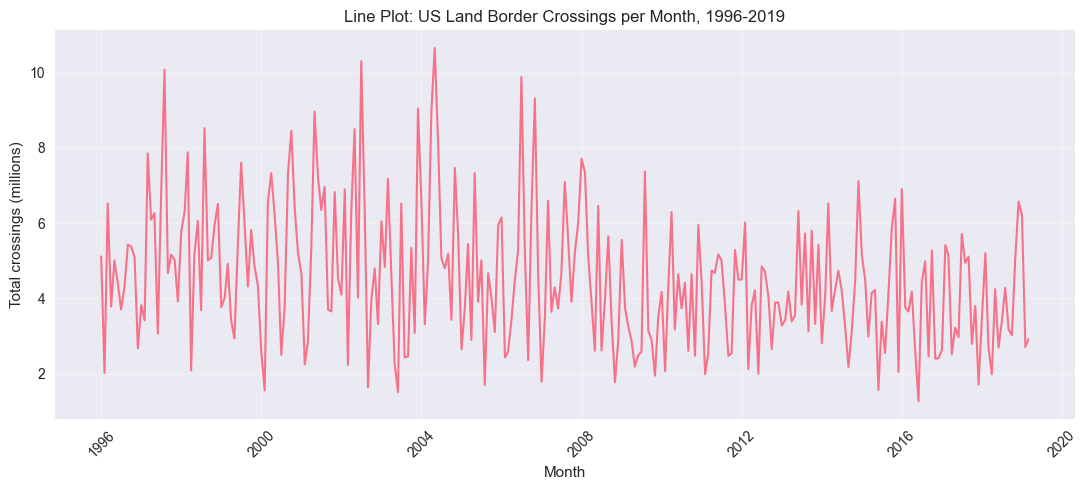

💡 Use for: Trends over time, continuous data
   The line shows a real long-term decline: the busiest month on record was May 2004 (10.6M crossings),
   against 2.9M in Mar 2019.
   Only a time-ordered line makes that shape visible at a glance.


In [2]:
# WHAT: Preview the data, then draw a line plot of monthly border traffic over time.
# WHY: Line plots are THE chart for trends - connected points emphasize change between moments.

print("Real data loaded:")
print(df[['Port Name', 'State', 'Border', 'Date', 'Measure', 'Value']].head())

# ============================================================================
# PART 2: MATPLOTLIB CHART TYPES
# ============================================================================
print("\n" + "=" * 70)
print("PART 2: Matplotlib Chart Types")
print("=" * 70)

# Line Plot
print("\n✅ Example 1: Line Plot (Trends Over Time)")
print("-" * 70)
plt.figure(figsize=(11, 5))
plt.plot(monthly.index, monthly.values / 1e6, linewidth=1.5)
plt.xlabel('Month')
plt.ylabel('Total crossings (millions)')
plt.title('Line Plot: US Land Border Crossings per Month, 1996-2019')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("💡 Use for: Trends over time, continuous data")
peak_month = monthly.idxmax()
print(f"   The line shows a real long-term decline: the busiest month on record was"
      f" {peak_month:%b %Y} ({monthly.max() / 1e6:.1f}M crossings),")
print(f"   against {monthly.iloc[-1] / 1e6:.1f}M in {monthly.index[-1]:%b %Y}.")
print("   Only a time-ordered line makes that shape visible at a glance.")



✅ Example 2: Bar Chart (Categorical Comparison)
----------------------------------------------------------------------


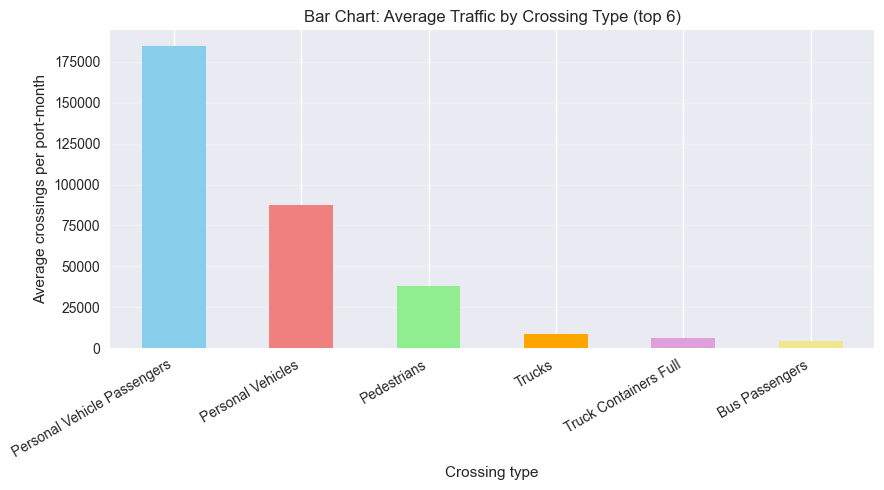

💡 Use for: Comparing categories, discrete data
   Averages per port-month:
Measure
Personal Vehicle Passengers    185044.0
Personal Vehicles               87506.0
Pedestrians                     38110.0
Trucks                           8368.0
Truck Containers Full            5881.0
Bus Passengers                   4349.0

✅ Example 3: Scatter Plot (Relationships)
----------------------------------------------------------------------


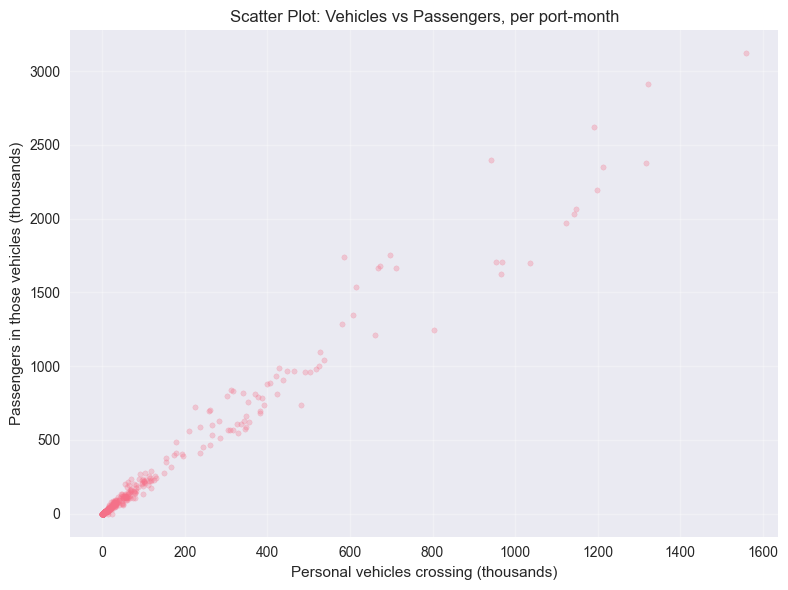

💡 Use for: Relationships, correlations, patterns
   These two measures move together almost perfectly (r = 0.99) -
   unsurprising, since every car carries people. The slope of the cloud is
   the average occupancy: about 2.1 people per vehicle.
   A scatter can measure something the two separate columns never showed.

✅ Example 4: Histogram (Distribution)
----------------------------------------------------------------------


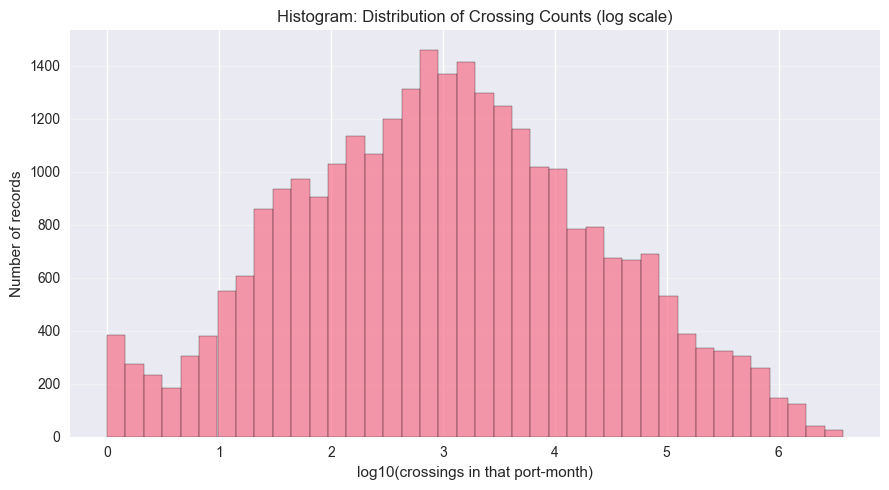

In [3]:
# WHAT: Draw a bar chart, a scatter plot and a histogram - each one built and shown in full.
# WHY: Bars compare categories; scatters expose relationships; histograms show shape. Matching chart to question is the core skill.

# Bar Chart
print("\n✅ Example 2: Bar Chart (Categorical Comparison)")
print("-" * 70)
category_means = df.groupby('Measure')['Value'].mean().sort_values(ascending=False).head(6)
plt.figure(figsize=(9, 5))
category_means.plot(kind='bar', color=['skyblue', 'lightcoral', 'lightgreen',
                                       'orange', 'plum', 'khaki'])
plt.xlabel('Crossing type')
plt.ylabel('Average crossings per port-month')
plt.title('Bar Chart: Average Traffic by Crossing Type (top 6)')
plt.xticks(rotation=30, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()
print("💡 Use for: Comparing categories, discrete data")
print("   Averages per port-month:")
print(category_means.round(0).to_string())

# Scatter Plot
print("\n✅ Example 3: Scatter Plot (Relationships)")
print("-" * 70)
# Each point is ONE port in ONE month: how many cars crossed, and how many people
# were in them. dropna() is needed because not every port reports every measure.
pair = wide[['Personal Vehicles', 'Personal Vehicle Passengers']].dropna()
plt.figure(figsize=(8, 6))
plt.scatter(pair['Personal Vehicles'] / 1000,
            pair['Personal Vehicle Passengers'] / 1000, alpha=0.3, s=15)
plt.xlabel('Personal vehicles crossing (thousands)')
plt.ylabel('Passengers in those vehicles (thousands)')
plt.title('Scatter Plot: Vehicles vs Passengers, per port-month')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
r = pair['Personal Vehicles'].corr(pair['Personal Vehicle Passengers'])
print("💡 Use for: Relationships, correlations, patterns")
print(f"   These two measures move together almost perfectly (r = {r:.2f}) -")
print("   unsurprising, since every car carries people. The slope of the cloud is")
print(f"   the average occupancy: about"
      f" {pair['Personal Vehicle Passengers'].sum() / pair['Personal Vehicles'].sum():.1f}"
      " people per vehicle.")
print("   A scatter can measure something the two separate columns never showed.")

# Histogram
print("\n✅ Example 4: Histogram (Distribution)")
print("-" * 70)
plt.figure(figsize=(9, 5))
# The raw Value column spans 0 to 4.4 million, so a linear histogram is one tall
# bar and 19 empty ones. log10 makes the real shape readable - and the axis label
# must say so, or the chart lies.
positive = df.loc[df['Value'] > 0, 'Value']
plt.hist(np.log10(positive), bins=40, edgecolor='black', alpha=0.7)
plt.xlabel('log10(crossings in that port-month)')
plt.ylabel('Number of records')
plt.title('Histogram: Distribution of Crossing Counts (log scale)')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


💡 Use for: Distributions, frequency, spread
   Raw range: 0 to 3,771,572 crossings.
   15,421 records are exactly 0 and had to be
   excluded before taking a logarithm - a real decision the data forced.

PART 3: Seaborn Chart Types

✅ Example 5: Box Plot (Statistical Summary)
----------------------------------------------------------------------


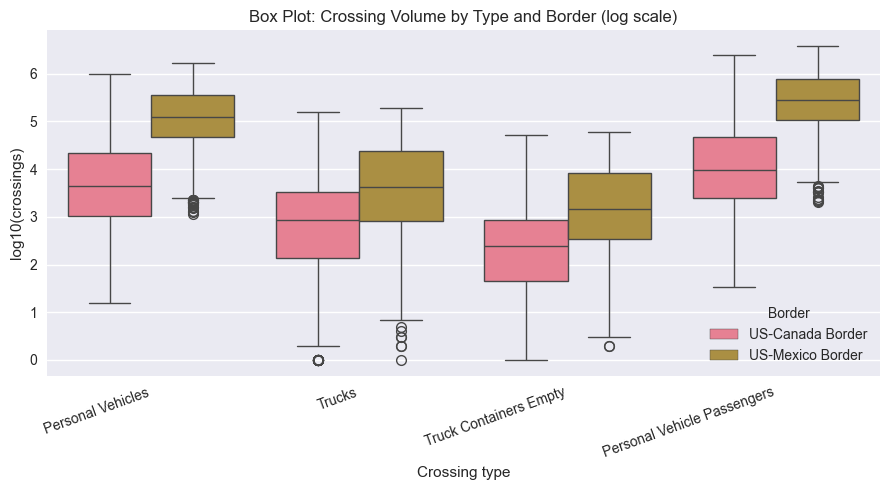

💡 Use for: Quartiles, outliers, distributions by category
   Median crossings per record, within the four types plotted:
     US-Mexico 41,084 vs US-Canada 1,932.
   The boxes sit at visibly different heights - a comparison that a single
   combined histogram would have hidden completely.


In [4]:
# WHAT: Comment on the histogram, then draw seaborn's box plot on the real data.
# WHY: Seaborn adds statistics on top of matplotlib - a box plot encodes median, quartiles, and outliers in one glyph.

print("💡 Use for: Distributions, frequency, spread")
print(f"   Raw range: {df['Value'].min():,.0f} to {df['Value'].max():,.0f} crossings.")
print(f"   {int((df['Value'] == 0).sum()):,} records are exactly 0 and had to be")
print("   excluded before taking a logarithm - a real decision the data forced.")

# ============================================================================
# PART 3: SEABORN CHART TYPES
# ============================================================================
print("\n" + "=" * 70)
print("PART 3: Seaborn Chart Types")
print("=" * 70)

# Box Plot
print("\n✅ Example 5: Box Plot (Statistical Summary)")
print("-" * 70)
top4 = df['Measure'].value_counts().head(4).index.tolist()
subset = df[df['Measure'].isin(top4) & (df['Value'] > 0)].copy()
subset['log_value'] = np.log10(subset['Value'])
plt.figure(figsize=(9, 5))
sns.boxplot(data=subset, x='Measure', y='log_value', hue='Border')
plt.title('Box Plot: Crossing Volume by Type and Border (log scale)')
plt.xlabel('Crossing type')
plt.ylabel('log10(crossings)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()
print("💡 Use for: Quartiles, outliers, distributions by category")
med = subset.groupby('Border')['Value'].median()
print(f"   Median crossings per record, within the four types plotted:")
print(f"     US-Mexico {med.get('US-Mexico Border', 0):,.0f} vs US-Canada {med.get('US-Canada Border', 0):,.0f}.")
print("   The boxes sit at visibly different heights - a comparison that a single")
print("   combined histogram would have hidden completely.")



✅ Example 6: Heatmap (Correlation Matrix)
----------------------------------------------------------------------


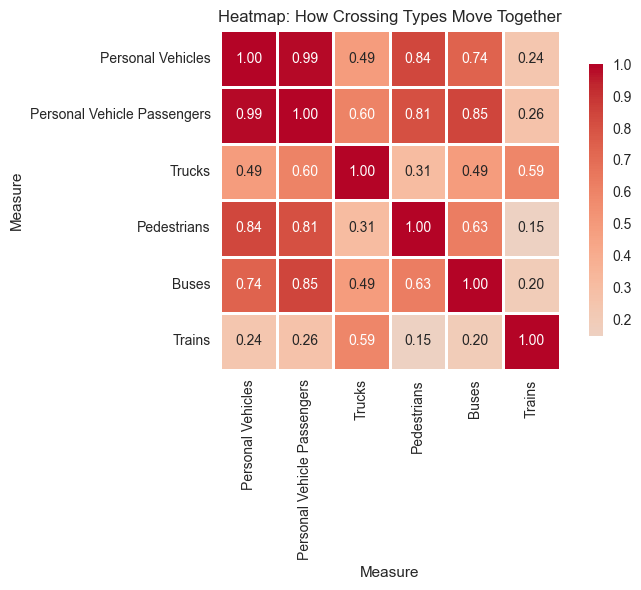

💡 Use for: Correlations, patterns in matrix data
   Strongest pair: Personal Vehicles ↔ Passengers (0.99)
   Weakest pair shown: Trains ↔ Pedestrians (0.15) - rail freight and people
   walking across a bridge are simply different kinds of traffic.
   One glance at the matrix replaces 15 separate scatter plots.

PART 4: Chart Selection Guide

📊 Distribution:
   Charts: Histogram, Box Plot, Violin Plot, KDE
   Use case: Show how data is distributed

📊 Relationships:
   Charts: Scatter Plot, Line Plot, Correlation Heatmap
   Use case: Show relationships between variables

📊 Comparisons:
   Charts: Bar Chart, Box Plot, Grouped Bar
   Use case: Compare categories or groups

📊 Composition:
   Charts: Pie Chart, Stacked Bar, Area Chart
   Use case: Show parts of a whole


In [5]:
# WHAT: Draw the correlation heatmap, then print a chart-selection guide organized by goal.
# WHY: Choosing by GOAL (distribution, relationship, comparison, composition) beats choosing by what looks nice.

# Heatmap
print("\n✅ Example 6: Heatmap (Correlation Matrix)")
print("-" * 70)
measures = ['Personal Vehicles', 'Personal Vehicle Passengers', 'Trucks',
            'Pedestrians', 'Buses', 'Trains']
correlation_data = wide[measures].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_data, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Heatmap: How Crossing Types Move Together')
plt.tight_layout()
plt.show()
print("💡 Use for: Correlations, patterns in matrix data")
print(f"   Strongest pair: Personal Vehicles ↔ Passengers"
      f" ({correlation_data.loc['Personal Vehicles', 'Personal Vehicle Passengers']:.2f})")
print(f"   Weakest pair shown: Trains ↔ Pedestrians"
      f" ({correlation_data.loc['Trains', 'Pedestrians']:.2f}) - rail freight and people")
print("   walking across a bridge are simply different kinds of traffic.")
print("   One glance at the matrix replaces 15 separate scatter plots.")

# ============================================================================
# ============================================================================
print("\n" + "=" * 70)
print("PART 4: Chart Selection Guide")
print("=" * 70)

selection_guide = {
    "Distribution": {
        "charts": ["Histogram", "Box Plot", "Violin Plot", "KDE"],
        "use_case": "Show how data is distributed"
    },
    "Relationships": {
        "charts": ["Scatter Plot", "Line Plot", "Correlation Heatmap"],
        "use_case": "Show relationships between variables"
    },
    "Comparisons": {
        "charts": ["Bar Chart", "Box Plot", "Grouped Bar"],
        "use_case": "Compare categories or groups"
    },
    "Composition": {
        "charts": ["Pie Chart", "Stacked Bar", "Area Chart"],
        "use_case": "Show parts of a whole"
    }
}

for purpose, info in selection_guide.items():
    print(f"\n📊 {purpose}:")
    print(f"   Charts: {', '.join(info['charts'])}")
    print(f"   Use case: {info['use_case']}")


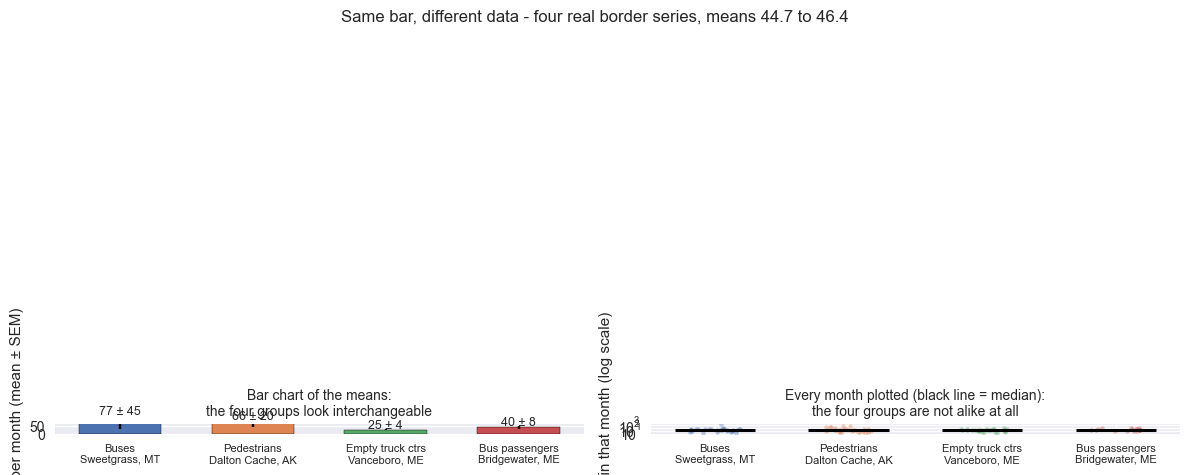


✅ Example 7: The case from the top of this notebook, on this data
----------------------------------------------------------------------
                            series  n_months  mean  SEM  median  IQR  max
                Buses @ Sweetgrass        30  77.1 45.0    27.5 40.5 1375
        Pedestrians @ Dalton Cache        31  65.6 20.0    16.0 27.5  455
Truck Containers Empty @ Vanceboro        27  24.7  4.2    20.0 18.5  111
      Bus Passengers @ Bridgewater        16  39.6  7.6    27.5 44.8  100

   Means span 24.7 to 77.1 - a 211.6% difference.
   Medians span 16.0 to 27.5, and the largest single month runs from 100 to 1,375.
   Weissgerber et al. (2015) counted 703 physiology papers that showed the left panel only.


In [6]:
# WHAT: Test the claim from the top of this notebook - "many different data distributions
#       produce the same bar graph" - on four REAL border series found by search, not by design.
# WHY: This is the whole lesson in one picture: the chart type, not the data, decided what the reader could see.

# Four real (crossing type, port) series whose mean and standard error are almost
# identical. They were not invented: the four were selected by scanning every
# port x measure series with at least 60 non-zero months and keeping a quartet
# whose means agree within 4% and whose standard errors agree within 20%.
PAIRS = [('Buses', 'Sweetgrass'),
         ('Pedestrians', 'Dalton Cache'),
         ('Truck Containers Empty', 'Vanceboro'),
         ('Bus Passengers', 'Bridgewater')]
LABELS = ['Buses\nSweetgrass, MT', 'Pedestrians\nDalton Cache, AK',
          'Empty truck ctrs\nVanceboro, ME', 'Bus passengers\nBridgewater, ME']
COLORS = ['#4c72b0', '#dd8452', '#55a868', '#c44e52']

nonzero = df[df['Value'] > 0]
groups = [nonzero[(nonzero['Measure'] == m) & (nonzero['Port Name'] == p)]['Value'].values
          for m, p in PAIRS]
means = [g.mean() for g in groups]
sems = [g.std(ddof=1) / np.sqrt(len(g)) for g in groups]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

# LEFT: the bar chart a report would print - mean with its standard error.
axes[0].bar(range(4), means, yerr=sems, capsize=6, color=COLORS,
            edgecolor='black', width=0.62)
axes[0].set_xticks(range(4))
axes[0].set_xticklabels(LABELS, fontsize=8)
axes[0].set_ylabel('Crossings per month (mean ± SEM)')
axes[0].set_ylim(0, 62)
axes[0].set_title('Bar chart of the means:\nthe four groups look interchangeable', fontsize=10)
for i, (m, s) in enumerate(zip(means, sems)):
    axes[0].text(i, m + s + 2, f"{m:.0f} ± {s:.0f}", ha='center', fontsize=9)

# RIGHT: the same numbers, every month drawn. Log axis because one Sweetgrass
# month reached 1,375 buses while medians sit near 20-30; on a linear axis that
# single point would flatten all four clouds into the floor.
rng = np.random.default_rng(0)          # jitter only - the DATA is real
for i, (g, c) in enumerate(zip(groups, COLORS)):
    axes[1].scatter(i + rng.uniform(-0.19, 0.19, size=len(g)), g,
                    s=8, alpha=0.35, color=c)
    axes[1].hlines(np.median(g), i - 0.3, i + 0.3, color='black', lw=2.2, zorder=3)
axes[1].set_yscale('log')
axes[1].set_xticks(range(4))
axes[1].set_xticklabels(LABELS, fontsize=8)
axes[1].set_ylabel('Crossings in that month (log scale)')
axes[1].set_title('Every month plotted (black line = median):\nthe four groups are not alike at all',
                  fontsize=10)
fig.suptitle('Same bar, different data - four real border series, means 44.7 to 46.4', fontsize=12)
fig.tight_layout()
plt.show()

print("\n✅ Example 7: The case from the top of this notebook, on this data")
print("-" * 70)
summary = pd.DataFrame({
    'series': [f"{m} @ {p}" for m, p in PAIRS],
    'n_months': [len(g) for g in groups],
    'mean': [round(g.mean(), 1) for g in groups],
    'SEM': [round(s, 1) for s in sems],
    'median': [float(np.median(g)) for g in groups],
    'IQR': [round(float(np.percentile(g, 75) - np.percentile(g, 25)), 1) for g in groups],
    'max': [int(g.max()) for g in groups],
})
print(summary.to_string(index=False))
print(f"\n   Means span {min(means):.1f} to {max(means):.1f} - a {100 * (max(means) - min(means)) / min(means):.1f}% difference.")
print(f"   Medians span {min(np.median(g) for g in groups):.1f} to {max(np.median(g) for g in groups):.1f}"
      f", and the largest single month runs from {min(int(g.max()) for g in groups):,}"
      f" to {max(int(g.max()) for g in groups):,}.")
print("   Weissgerber et al. (2015) counted 703 physiology papers that showed the left panel only.")


**Read the figure.** Both panels are the same four real series, the same 862 monthly
numbers. On the **left**, four bars of mean ± SEM at 45, 46, 46 and 46 crossings a month
with error bars that all overlap: nothing to report. On the **right**, every one of those
months is a dot. Sweetgrass buses stay under 121 in 99% of months and then hit **1,375**
once — the lone dot at the top; Dalton Cache pedestrians and Vanceboro containers run all
the way from 1 to over 400 with medians of 20 and 19.5; Bridgewater is visibly the thinnest
column because it has only **92 months of data**, against 278 for Sweetgrass. Same numbers,
opposite conclusions — and the reader of the left panel has no way to know.

That is the lesson of this notebook stated as a picture: **the chart type is part of the
claim.** When a group is small enough to draw, draw it — the strip plot on the right cost
one extra line of code and removed the ambiguity the bar introduced.


## 💬 Discuss

Three real findings from the charts above: the busiest month on record was **July 2000
with 50.2 million crossings**, against **31.0 million in March 2019**; personal vehicles
and their passengers correlate at **r = 0.98**, implying about **2.1 people per vehicle**;
and **122,387 records are exactly zero** and had to be dropped before taking a logarithm.

1. The line chart shows a long, real decline from 2000 to 2019. Name two explanations that
   have nothing to do with fewer people wanting to cross, and say which column in this file
   — or which column *not* in this file — would let you distinguish them.
2. Dropping 122,387 zeros to allow a log scale changed which records the histogram
   describes. State plainly what the histogram is now a histogram *of*, and write the
   caption you would put under it so a reader is not misled.
3. The r = 0.98 between vehicles and passengers is close to perfect. Is that a discovery, or
   is it the same measurement counted twice? Argue it — then say what you would do with
   these two columns if you were about to build a model.


In [7]:
# WHAT: Print the notebook summary.
# WHY: The one-line rules here (distribution -> histogram, relationship -> scatter) are worth memorizing.

print("\n" + "=" * 70)
print("Summary")
print("=" * 70)
print("""
✅ What you learned:
   1. Matplotlib Charts: Line, bar, scatter, histogram (basic plots)
   2. Seaborn Charts: Box plot, heatmap, distribution plots (statistical)
   3. Chart Selection: Choose based on data type and goal
   4. When to Use: Distribution → histogram, Relationships → scatter
   5. Real data forces real decisions: log scales for skewed counts,
      dropna() before a scatter, zeros excluded before a logarithm

🎯 Key Takeaways:
   - Matplotlib: Basic, customizable plots
   - Seaborn: Statistical, beautiful plots
   - Choose chart based on: Data type, goal, audience

📚 Next Steps:
   - Example 02: Matplotlib Basics (more details)
   - Example 03: Seaborn Plots (advanced statistical charts)
   - Examples 04-05: Interactive Visualizations (Plotly)
""")
print("✅ Chart types concepts understood!")



Summary

✅ What you learned:
   1. Matplotlib Charts: Line, bar, scatter, histogram (basic plots)
   2. Seaborn Charts: Box plot, heatmap, distribution plots (statistical)
   3. Chart Selection: Choose based on data type and goal
   4. When to Use: Distribution → histogram, Relationships → scatter
   5. Real data forces real decisions: log scales for skewed counts,
      dropna() before a scatter, zeros excluded before a logarithm

🎯 Key Takeaways:
   - Matplotlib: Basic, customizable plots
   - Seaborn: Statistical, beautiful plots
   - Choose chart based on: Data type, goal, audience

📚 Next Steps:
   - Example 02: Matplotlib Basics (more details)
   - Example 03: Seaborn Plots (advanced statistical charts)
   - Examples 04-05: Interactive Visualizations (Plotly)

✅ Chart types concepts understood!


## ⚠️ Where this breaks

- **A chart type encodes a claim about your data, and the claim can be false.** A line plot
  asserts that consecutive points are connected in a meaningful order — draw one across
  categories and you have invented a trend. A pie chart asserts the parts sum to a
  meaningful whole. A bar of means asserts the mean is representative, which lesson 03's
  skewness of 4.80 says it often is not.
- **Aggregation happens before the chart, and the chart cannot show what it removed.** The
  monthly line above is a sum over 116 ports; a port that collapsed and a port that boomed
  cancel out perfectly and the line stays flat.
- **Correlation heatmaps look like conclusions.** The 0.98 between vehicles and passengers
  is two views of one phenomenon; the 0.12 between trains and pedestrians is two unrelated
  phenomena. The colours in the grid make both look like findings of the same type.
- **The assumption that must hold: the reader shares your reference frame.** A log axis, a
  truncated y-axis or a dual axis are all legitimate and all routinely misread. If a
  choice needs explaining, put the explanation *in the chart*, not in the caption nobody
  reads.
- **When not to chart at all:** with three numbers, a sentence is clearer than a bar chart.
  With 346,733 rows and a question of the form "is A bigger than B, and by how much?", a
  table with a confidence interval is more honest than any picture, because a picture
  cannot express uncertainty that you did not compute.
- **Cheaper alternative for small samples:** plot the individual points. Weissgerber's whole
  argument is that with n below roughly 20, a strip plot or dot plot showing every
  observation costs no extra work and removes the ambiguity a bar introduces.


## 📚 References

1. Cleveland, W. S., & McGill, R. (1984). *Graphical Perception: Theory, Experimentation, and Application to the Development of Graphical Methods*. Journal of the American Statistical Association, 79(387), 531-554. <https://doi.org/10.1080/01621459.1984.10478080>
2. Tufte, E. R. (2001). *The Visual Display of Quantitative Information*, 2nd ed. Graphics Press.
3. Waskom, M. L. (2021). *seaborn: Statistical Data Visualization*. Journal of Open Source Software, 6(60), 3021. <https://joss.theoj.org/papers/10.21105/joss.03021>
4. Chen, N., Zhang, Y., Xu, J., Ren, K., & Yang, Y. (2024). *VisEval: A Benchmark for Data Visualization in the Era of Large Language Models*. arXiv:2407.00981. <https://arxiv.org/abs/2407.00981>
5. Xie, Y., Zhang, Z., Wu, Y., et al. (2025). *VisJudge-Bench: Aesthetics and Quality Assessment of Visualizations*. arXiv:2510.22373. <https://arxiv.org/abs/2510.22373>
